# aerialdrm Hurricane Model

Explanation and demo

In [18]:
from aerialdrm.hurricane.hurricaneaircraft import HurricaneAircraftArchitecture
from fmdtools.define.architecture.function import FunctionArchitectureGraph

The hurricane aircraft architecture follows our desired FRDL architecture:

In [19]:
ha = HurricaneAircraftArchitecture()
ha

hurricaneaircraftarchitecture HurricaneAircraftArchitecture
FUNCTIONS:
control_flight HurricaneControlFlight
- ControlState(flightplan=((0.0, 0.0), (50.0, 0.0), (50.0, 100.0), (100.0, 1...
aviate Aviate
- AviateMode(mode=idle, faults=set())
store_and_supply_ee StoreAndSupplyElectricity
- StoreEEMode(mode=nominal, faults=set())
perceive_environment PerceiveEnvironment
hold_payload HoldPayload
- HoldPayloadMode(mode=nominal, faults=set())
FLOWS:
force Force flow: ForceState(weight=1.0, contact_support=0.0, lift_support=1.0)
electricity Electricity flow: ElectricityState(charge=100.0, voltage_high=1.0, current_high=1.0, power_high=False,...

trajectories Trajectories flow: AircraftPosition3(x=0.0, goal_x=10.0, dx=0.0, y=0.0, goal_y=10.0, dy=0.0, z=0.0, g...

environment HurricaneEnvironment

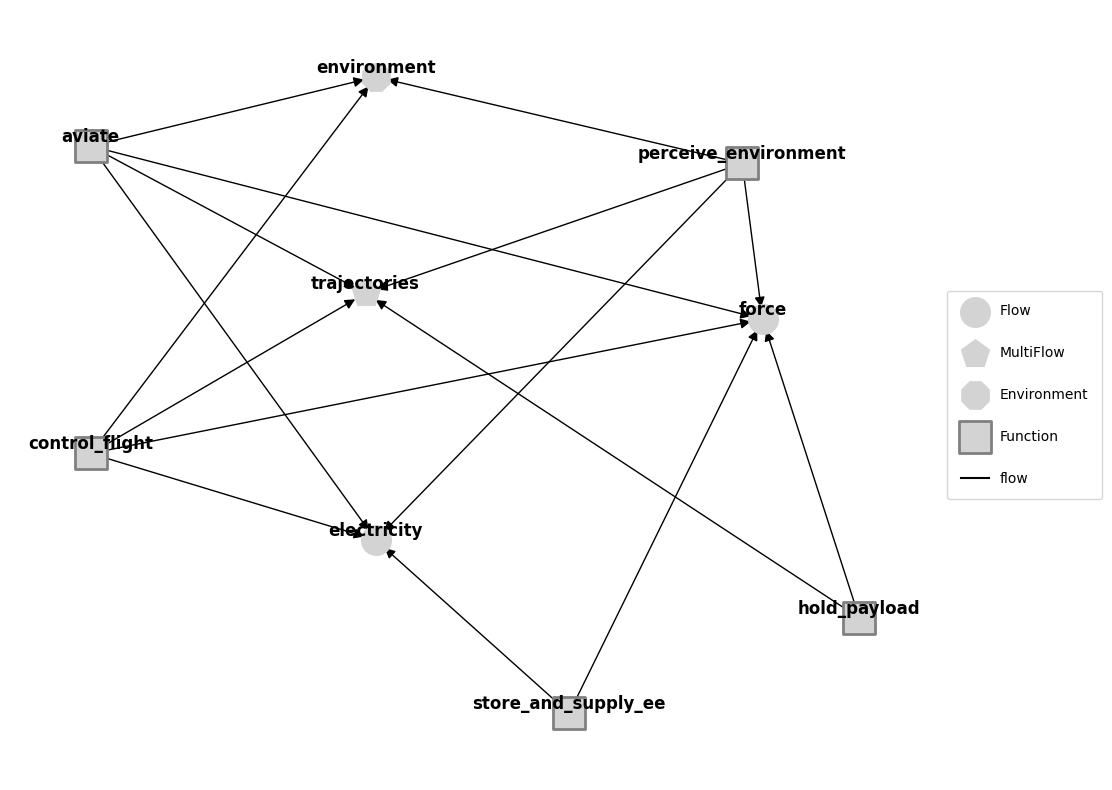

In [20]:
fg = FunctionArchitectureGraph(ha)
pos = {'hurricaneaircraftarchitecture.flows.force': [0.53, 0.25],
       'hurricaneaircraftarchitecture.flows.electricity': [-0.23, -0.26],
       'hurricaneaircraftarchitecture.flows.trajectories': [-0.25, 0.31],
       'hurricaneaircraftarchitecture.flows.environment': [-0.23, 0.81],
       'hurricaneaircraftarchitecture.fxns.control_flight': [-0.79, -0.06],
       'hurricaneaircraftarchitecture.fxns.aviate': [-0.79, 0.65],
       'hurricaneaircraftarchitecture.fxns.store_and_supply_ee': [0.15, -0.66],
       'hurricaneaircraftarchitecture.fxns.perceive_environment': [0.49, 0.61],
       'hurricaneaircraftarchitecture.fxns.hold_payload': [0.72, -0.44]}
fg.set_edge_labels(title='')
fg.set_pos(**pos)
fig, ax = fg.draw()
fig.savefig("hac_arch.pdf")

In [21]:
# %matplotlib qt5
# fg.move_nodes()
# %matplotlib inline

## Environment

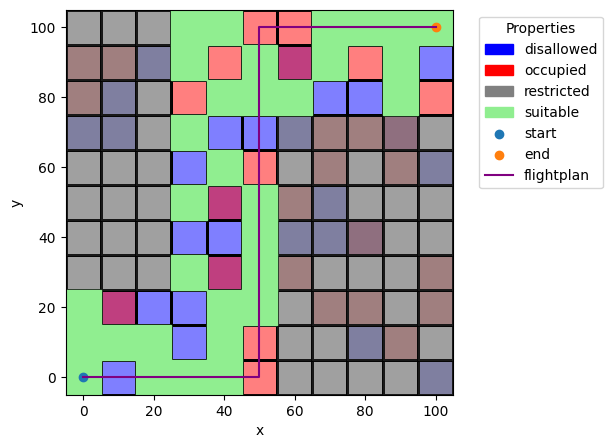

In [37]:
from aerialdrm.hurricane.hurricaneenvironment import properties, collections
from fmdtools.analyze.common import consolidate_legend
fig, ax = ha.flows['environment'].c.show(properties=properties, collections=collections)
ax.scatter([0], [0], label="start")
ax.scatter([100], [100], label="end")
xs = [x[0] for x in ha.p.flightplan]
ys = [x[1] for x in ha.p.flightplan]
ax.plot(xs, ys, label="flightplan", color="purple")
consolidate_legend(ax)